Extended Data Figure 2 — Cell-level quality control metrics for TEA-seq libraries


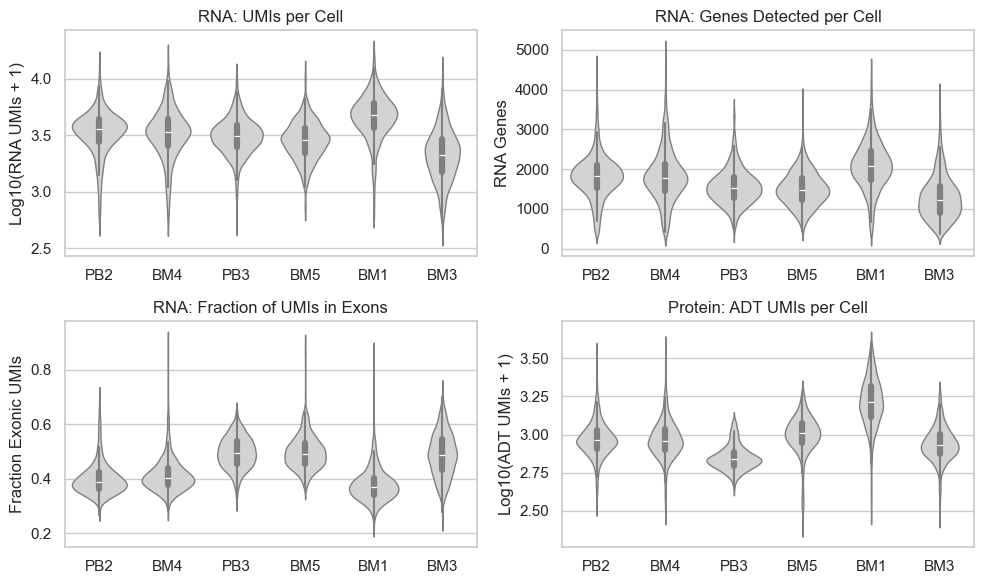

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Base directory
base_dir = "PATH_TO_DATA/Metrics"

# Patient files
patient_files = {
    "BM1": f"{base_dir}/BM1/metrics_paper_final.csv",
    "BM3": f"{base_dir}/BM3/metrics_paper_final.csv",
    "BM4": f"{base_dir}/BM4/metrics_paper_final.csv",
    "BM5": f"{base_dir}/BM5/metrics_paper_final.csv",
    "PB2": f"{base_dir}/PB2/metrics_paper_final.csv",
    "PB3": f"{base_dir}/PB3/metrics_paper_final.csv",
}

# Read and combine
dfs = []
for patient, path in patient_files.items():
    df = pd.read_csv(path)
    df["Patient"] = patient
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# Compute exon fraction
df["RNA_exon_fraction"] = df["gex_exonic_umis"] / df["gex_umis_count"]

# Patient order (UPDATED)
patient_order = ["PB2", "BM4", "PB3", "BM5", "BM1", "BM3"]
df["Patient"] = pd.Categorical(df["Patient"], categories=patient_order, ordered=True)

# Plot
sns.set(style="whitegrid", context="notebook")

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.violinplot(ax=axes[0,0], data=df, x="Patient", y="RNA_log10_umis",
               inner="box", cut=2, linewidth=1, color="lightgray")
axes[0,0].set_title("RNA: UMIs per Cell")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Log10(RNA UMIs + 1)")

sns.violinplot(ax=axes[0,1], data=df, x="Patient", y="gex_genes_count",
               inner="box", cut=2, linewidth=1, color="lightgray")
axes[0,1].set_title("RNA: Genes Detected per Cell")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("RNA Genes")

sns.violinplot(ax=axes[1,0], data=df, x="Patient", y="RNA_exon_fraction",
               inner="box", cut=2, linewidth=1, color="lightgray")
axes[1,0].set_title("RNA: Fraction of UMIs in Exons")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Fraction Exonic UMIs")

sns.violinplot(ax=axes[1,1], data=df, x="Patient", y="ADT_log10_umis",
               inner="box", cut=2, linewidth=1, color="lightgray")
axes[1,1].set_title("Protein: ADT UMIs per Cell")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Log10(ADT UMIs + 1)")

plt.tight_layout()
plt.show()
